## Introduction

We will tune a Logistic Regression model to predict shark attack fatality.

## Import the libraries

In [56]:
# For GeoPandas dataframes
!pip install geopandas

In [57]:
# For Geohashes
!pip install pygeohash

In [58]:
# For TargetEncoder to encode Geohashes
!pip install category_encoders

In [59]:
import numpy as np
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point
import pygeohash as pgh

import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import matplotlib

from sklearn import tree

from sklearn.compose import make_column_selector as col_selector
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder


from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.metrics import confusion_matrix

from sklearn.inspection import DecisionBoundaryDisplay

pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline 

## Setup Colors

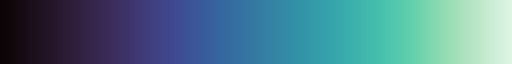

In [61]:
palette_str = 'mako'
palette_str_r = 'mako_r'
palette = sns.color_palette(palette_str)
palette_r = sns.color_palette(palette_str_r)
cmap = sns.color_palette(palette_str, as_cmap=True)
cmap_r = sns.color_palette(palette_str_r, as_cmap=True)
cmap


['#2e1e3b', '#413d7b', '#37659e', '#348fa7', '#40b7ad', '#8bdab2']


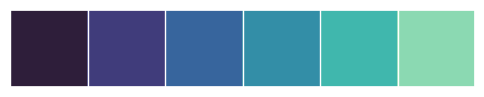

In [62]:
print(palette.as_hex())
sns.palplot(palette)
plt.show()

In [63]:
'''
Setting the CSS
'''
from IPython.display import HTML
style="""
<style>
    div.info { 
        background-color: #40b7ad;
        border-color: #40b7ad; 
        color: white;
        border-radius: 10px;
        width: 800px;
        padding: 2em;
        font-weight: bold;
        font-family: Verdana;
    }
</style>"""
HTML(style)

<div class='info'>This is an Info Box</div>

## Clean the data

In [66]:
# Read the geoencoded data into a standard data frame
# This data was geoencoded using Goole Maps API and Google spreadsheet plugin
# Original data: https://www.kaggle.com/datasets/gauravkumar2525/shark-attacks/data
df = pd.read_csv('geocoded-global-shark-attacks.csv')

# Assign name for columns
columns = (["Date", "Year", "Type", "Country", "Area", "Location", "Activity", "Name", "Gender", "Age", "Fatal", "Time", 
            "Species", "GeoAreaCountry", "GeoLocationAreaCountry", "Latitude", "Longitude"])
df.columns = columns

df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude
0,2023-05-13,2023.0,Unprovoked,AUSTRALIA,South Australia,Elliston,Surfing,Simon Baccanello,M,46,Y,10h10,White shark,"South Australia, AUSTRALIA","Elliston, South Australia, AUSTRALIA",-33.647648,134.89151
1,2023-04-29,2023.0,Unprovoked,AUSTRALIA,Western Australia,"Yallingup, Busselton",Swimming,male,M,NaN,N,11h20,1m shark,"Western Australia, AUSTRALIA","Yallingup, Busselton, Western Australia, AUSTR...",-33.639694,115.02619
2,2022-10-07,2022.0,Unprovoked,AUSTRALIA,Western Australia,Port Hedland,Spearfishing,Robbie Peck,M,38,N,11h30,Bull shark,"Western Australia, AUSTRALIA","Port Hedland, Western Australia, AUSTRALIA",-20.313017,118.57681
3,2021-10-04,2021.0,Unprovoked,USA,Florida,"Fort Pierce State Park, St. Lucie County",Surfing,Truman Van Patrick,M,25.0,N,NaN,NaN,"Florida, USA","Fort Pierce State Park, St. Lucie County, Flor...",27.446976,-80.32606
4,2021-10-03,2021.0,Unprovoked,USA,Florida,"Jensen Beach, Martin County",Swimming,male,M,NaN,N,12h00,NaN,"Florida, USA","Jensen Beach, Martin County, Florida, USA",27.244460,-80.22529


In [67]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

1


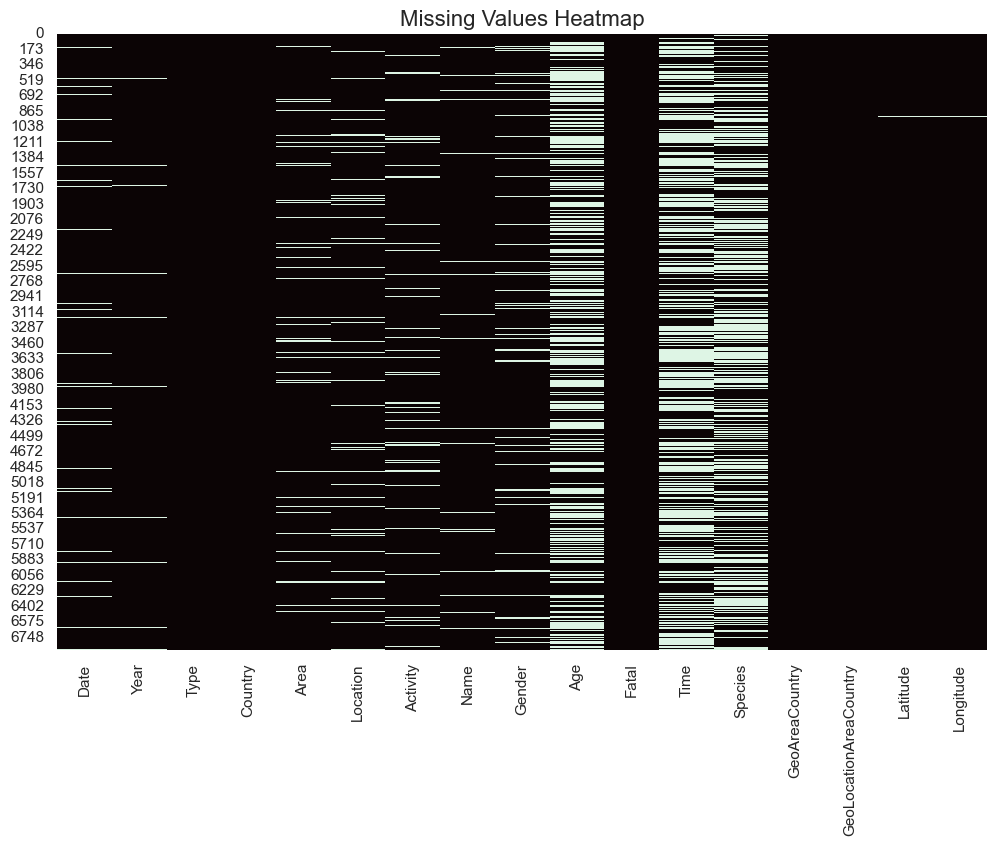

In [68]:
# Visualize missing values as a heatmap
# Source: https://medium.com/@HildaPosada/finding-and-visualizing-missing-data-in-python-using-missingno-and-seaborn-d4cf0452b9e9
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=palette_str)
plt.title('Missing Values Heatmap', fontsize=16)
plt.savefig('missing-values-heatmap.png', dpi=400)
plt.show()

In [69]:
"""
Cleaning Fatal

The Fatal data is binary either Yes or No.
"""
df["Fatal"] = df["Fatal"].replace("Y",1)
df["Fatal"] = df["Fatal"].replace("y",1)
df["Fatal"] = df["Fatal"].replace("F",1)
df["Fatal"] = df["Fatal"].replace("Y x 2",1)
df["Fatal"] = df["Fatal"].replace("N",0)
df["Fatal"] = df["Fatal"].replace("n",0)
df["Fatal"] = df["Fatal"].replace("Nq",0)  # A single record. Looked up name of victim. She survived.
df["Fatal"] = df["Fatal"].replace("2017.0",0) # Another single record. Looked up name and he survived.
df["Fatal"] = df["Fatal"].replace("UNKNOWN",None)

# Drop the more sparse NA (based on the missing values graph)
df.dropna(subset=["Fatal"], inplace=True)
df.dropna(subset=["Latitude"], inplace=True)
df.dropna(subset=["Longitude"], inplace=True)
df.dropna(subset=["Year"], inplace=True)
df.dropna(subset=["Type"], inplace=True)
df.dropna(subset=["Location"], inplace=True)



"""
Cleaning Date
"""
# Replace NaN with None
df["Date"] = df["Date"].replace("nan", None) 
df.dropna(subset=["Date"], inplace=True)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Save the Month as this is important. It can map to shark breeding behavior.
df["Month"] = df["Date"].dt.month_name()
df["Month"] = df["Month"].fillna("Unknown")
df["Month"].value_counts()




"""
Cleaning Type
"""
df = df.drop(df[df["Type"] == "Invalid"].index) # Remove invalid record
df = df.drop(df[df["Type"] == "Questionable"].index) # Remove Questionable record
df["Type"] = df["Type"].replace("?","Unknown")
df["Type"] =  df["Type"].fillna("Unknown")
df["Type"] = df["Type"].astype(object)


"""
Cleaning Gender
"""
df["Gender"] = df["Gender"].replace("M x 2","M")
df["Gender"] = df["Gender"].replace("nan", "Unknown") 
df["Gender"] = df["Gender"].replace("N", "Unknown") 
df["Gender"] = df["Gender"].replace(".", "Unknown") 
df["Gender"] = df["Gender"].replace("lli", "Unknown")
df["Gender"] = df["Gender"].replace("", "Unknown")


df["Gender"] = df["Gender"].fillna("Unknown")
df["Gender"] = df["Gender"].astype(object)


"""
Cleaning Age
"""
def numeric_age(value):
    if not value:
        return None
    
    if value.isdigit():
        value = int(value)

    try:
        value = float(value)
    except ValueError:
        return None
    
    return value


# Everything else with NaN replace with None
df = df.applymap(lambda x: None if pd.isna(x) else x)

df["Age"] = df["Age"].map(numeric_age)
df["Age"] = df["Age"].fillna(df["Age"].median()) # Apply median to fill NA

"""
Cleaning Activity
"""
df["Activity"] =  df["Activity"].fillna("Unknown")
others = []

import re

def clean_activity_name(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    
    if re.search("spear", value.lower()):
        return "Spearfishing"
    elif re.search("(fishing|crabbing)", value.lower()):
        return "Fishing"
    elif re.search("(body surfing|body-surfing)", value.lower()):
        return "Body Surfing"
    elif re.search("(snorkeling|snorkling)", value.lower()):
        return "Snorkeling"
    elif re.search("(surf-skiing|surfskiing|surf skiing)", value.lower()):
        return "Surf-skiing"
    elif re.search("kayaking", value.lower()):
        return "Kayaking"
    elif re.search("filming", value.lower()):
        return "Filming"
    elif re.search("(surfing|body boarding|boogie|surf\s+board|surfboard|body-boarding)", value.lower()):
        return "Surfing"
    elif re.search("surf ski", value.lower()):
        return "Surf-skiing"
    elif re.search("(swim|treading)", value.lower()):
        return "Swimming"
    elif re.search("(diving|dived|dive)", value.lower()):
        return "Diving"
    elif re.search("(bathed|bathing)", value.lower()):
        return "Bathing"
    elif re.search("tsunami", value.lower()):
        return "Tsunami"
    elif re.search("outrigger", value.lower()):
        return "Outrigger"
    elif re.search("(kite\s+boarding|kite-boarding|kiteboarding)", value.lower()):
        return "Kite Boarding"
    elif re.search("(foil boarding|foil-boarding|kite foiling)", value.lower()):
        return "Foil Boarding"
    elif re.search("rowing", value.lower()):
        return "Rowing"
    elif re.search("floating", value.lower()):
        return "Floating"
    elif re.search("(sup|paddleboarding|paddleboard|paddle\s+boarding|paddle-boarding)", value.lower()):
        return "SUP"
    elif re.search("(wading|shallows|standing)", value.lower()):
        return "Wading"
    elif re.search("playing", value.lower()):
        return "Playing"
    elif re.search("paddling", value.lower()):
        return "Paddling"
    elif re.search("canoeing", value.lower()):
        return "Canoeing"
    elif re.search("fell", value.lower()):
        return "Fell"
    elif re.search("jumping", value.lower()):
        return "Jumping"
    elif re.search("walking", value.lower()):
        return "Walking"
    elif re.search("shark", value.lower()):
        return "Direct Contact"
    elif re.search("(boat accident|capsize|sunk|sink|sank|overboard|adrift|ship|explosion|destroyer|freighter|torpedo|shipwrecked|wrecked|wreck|swamped|founder|sea disaster|ship wreck)", value.lower()):
        return "Boat Accident"
    elif re.search("(airline|aircraft|crash|plane)", value.lower()):
        return "Air Accident"
    else:
        others.append(value)
        return value
        

df["Activity"] = df["Activity"].apply(lambda x: " ".join(x.split())) # strip extra whitespace from string
df["Activity"] = df["Activity"].map(clean_activity_name)
df["Activity"] = df["Activity"].astype(object)


"""
Cleaning Country
"""
df["Country"] = df["Country"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Country"] = df["Country"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Country"] = df["Country"].astype(object)


"""
Cleaning Area
"""
df["Area"] = df["Area"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Area"] = df["Area"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())
df["Area"] = df["Area"].astype(object)



"""
Location
"""
df["Location"] = df["Location"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Location"] = df["Location"].apply(lambda x: "Unknown" if pd.isna(x) else x.upper())



"""
Cleaning Species
"""
others = []
def clean_species(value):
    if not isinstance(value, str):
        others.append(value)
        return "Unknown"
    # Note: Order of conditional matters
    if re.search("sand", value.lower()):
        return "Sand Shark"
    elif re.search("(raggedtooth| ragged tooth)", value.lower()):
        return "Raggedtooth Shark"
    elif re.search("(bull|zambezi|zambesi|leucas)", value.lower()):
        return "Bull Shark"
    elif re.search("lemon", value.lower()):
        return "Lemon Shark"
    elif re.search("thresher", value.lower()):
        return "Thresher Shark"
    elif re.search("nurse", value.lower()):
        return "Nurse Shark"
    elif re.search("(hammerhead|hammer head)", value.lower()):
        return "Hammerhead Shark"
    elif re.search("(blacktip|black tip)", value.lower()):
        return "Blacktip Shark"
    elif re.search("(copper|bronze|whaler|narrowtooth)", value.lower()):
        return "Copper Shark"
    elif re.search("(whale|while shark)", value.lower()):
        return "Whale Shark"
    elif re.search("mako", value.lower()):
        return "Mako Shark"
    elif re.search("(leopard|leapord)", value.lower()):
        return "Leopard Shark"
    elif re.search("blue", value.lower()):
        return "Blue Shark"
    elif re.search("spinner", value.lower()):
        return "Spinner Shark"
    elif re.search("wobbegong", value.lower()):
        return "Wobbegong Shark"
    elif re.search("carpet", value.lower()):
        return "Carpet Shark"
    elif re.search("reef", value.lower()):
        return "Reef Shark" 
    elif re.search("(dusky|c. obscurus|carcharhinus obscurus)", value.lower()):
        return "Dusky Shark"   
    elif re.search("angel", value.lower()):
        return "Angel Shark" 
    elif re.search("shovelnose", value.lower()):
        return "Shovelnose Shark" 
    elif re.search("sharpnose", value.lower()):
        return "Sharpnose Shark" 
    elif re.search("(sevengill|seven-gill|seven gill)", value.lower()):
        return "Sevengill Shark"
    elif re.search("(galapagos|galapagensis)", value.lower()):
        return "Galapagos Shark"
    elif re.search("(grey|gray|Carcharhinus)", value.lower()):
        return "Gray Shark"
    elif re.search("(whitetip| white tip)", value.lower()):
        return "Whitetip Shark"
    elif re.search("(white|great)", value.lower()):
        return "White Shark"
    elif re.search("tiger", value.lower()):
        return "Tiger Shark"
    else:
        others.append(value)
        return value


df["Species"] = df["Species"].apply(lambda x: " ".join(x.split()) if not pd.isna(x) else x) # strip extra whitespace from string
df["Species"] = df["Species"].map(clean_species)
df["Species"] = df["Species"].astype(object)
df["Species"] = df["Species"].apply(lambda x: "Unknown" if pd.isna(x) else x)
print("Species values: ", df["Species"].value_counts())

# Leaving Species N/A as Unknown because there should be a correlation between fatality and no report / sighting of species

# Final cleaning
df["Area"] =  df["Area"].fillna("Unknown")


Species values:  Species
Unknown                                                                    2504
White Shark                                                                 637
Tiger Shark                                                                 258
Bull Shark                                                                  232
Blacktip Shark                                                              123
                                                                           ... 
Unidentified shark                                                            1
170-kg, 2.8 m shark                                                           1
3.7 to 4.5 m [12' to 15'] shark seen in vicinity                              1
Reported as a shark bite but toothmarks appear to be those of a dolphin       1
Said to be a 7.6 m [25'] shark                                                1
Name: count, Length: 387, dtype: int64


In [70]:
"""
Create the Geohashes
"""
# Convert the geo data to a GeoDataFrame
# EPSG:4326 is the widely used code for the WGS 84 geographic coordinate system
loc_crs = {'init': 'epsg:4326'}
loc_geom = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
geo_df = gpd.GeoDataFrame(df, crs=loc_crs, geometry=loc_geom)

# Geohash can determine proximity but fails if point is across geohash grid boundary
# Points near 180 degress meridian may have very different Geohashes
# Precision decreases near the polls
# Cells have different physical areas at different latitudes

"""
Geohash precision:
1   5,009.4km x 4,992.6km
2   1,252.3km x 624.1km
3   156.5km x 156km
4   39.1km x 19.5km
5   4.9km x 4.9km
6   1.2km x 609.4m
7   152.9m x 152.4m
8   38.2m x 19m
9   4.8m x 4.8m
10  1.2m x 59.5cm
11  14.9cm x 14.9cm
12  3.7cm x 1.9cm 
"""
# Precision 8 yielded best initial scores
# But we can use Geohashes to create a sort of bounding box of different sizes
geo_df['Geohash P4'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=4), axis=1)
geo_df['Geohash P5'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=5), axis=1)
geo_df['Geohash P6'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=6), axis=1)
geo_df['Geohash P7'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=7), axis=1)
geo_df['Geohash P8'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=8), axis=1)
geo_df['Geohash P9'] = df.apply(lambda row: pgh.encode_strictly(row['Latitude'], row['Longitude'], precision=9), axis=1)


def get_hemisphere(latitude):
    """
    Determines the hemisphere (Northern or Southern) based on latitude.

    Args:
        latitude (float): The latitude of the geographic point.

    Returns:
        str: "Northern" if latitude > 0,
             "Southern" if latitude < 0,
             "Equator" if latitude == 0.
    """
    if latitude > 0:
        return "Northern"
    elif latitude < 0:
        return "Southern"
    else:
        return "Equator"

geo_df['Hemisphere'] = df.apply(lambda row: get_hemisphere(row['Latitude']), axis=1)



geo_df.head()

,Date,Year,Type,Country,Area,Location,Activity,Name,Gender,Age,Fatal,Time,Species,GeoAreaCountry,GeoLocationAreaCountry,Latitude,Longitude,Month,geometry,Geohash P4,Geohash P5,Geohash P6,Geohash P7,Geohash P8,Geohash P9,Hemisphere
0,2023-05-13,2023.0,Unprovoked,AUSTRALIA,SOUTH AUSTRALIA,ELLISTON,Surfing,Simon Baccanello,M,46.0,1,10h10,White Shark,"South Australia, AUSTRALIA","Elliston, South Australia, AUSTRALIA",-33.647648,134.89151,May,POINT (134.89151 -33.64765),qfpb,qfpbt,qfpbtd,qfpbtd8,qfpbtd8u,qfpbtd8up,Southern
1,2023-04-29,2023.0,Unprovoked,AUSTRALIA,WESTERN AUSTRALIA,"YALLINGUP, BUSSELTON",Swimming,male,M,24.0,0,11h20,1m shark,"Western Australia, AUSTRALIA","Yallingup, Busselton, Western Australia, AUSTR...",-33.639694,115.02619,April,POINT (115.02619 -33.63969),qd1b,qd1b9,qd1b9k,qd1b9kp,qd1b9kpd,qd1b9kpd8,Southern
2,2022-10-07,2022.0,Unprovoked,AUSTRALIA,WESTERN AUSTRALIA,PORT HEDLAND,Spearfishing,Robbie Peck,M,38.0,0,11h30,Bull Shark,"Western Australia, AUSTRALIA","Port Hedland, Western Australia, AUSTRALIA",-20.313017,118.57681,October,POINT (118.57681 -20.31302),qskk,qskk6,qskk6q,qskk6q0,qskk6q0u,qskk6q0up,Southern
3,2021-10-04,2021.0,Unprovoked,USA,FLORIDA,"FORT PIERCE STATE PARK, ST. LUCIE COUNTY",Surfing,Truman Van Patrick,M,25.0,0,None,Unknown,"Florida, USA","Fort Pierce State Park, St. Lucie County, Flor...",27.446976,-80.32606,October,POINT (-80.32606 27.44698),dhyu,dhyuh,dhyuhh,dhyuhhs,dhyuhhs6,dhyuhhs65,Northern
4,2021-10-03,2021.0,Unprovoked,USA,FLORIDA,"JENSEN BEACH, MARTIN COUNTY",Swimming,male,M,24.0,0,12h00,Unknown,"Florida, USA","Jensen Beach, Martin County, Florida, USA",27.244460,-80.22529,October,POINT (-80.22529 27.24446),dhyf,dhyfy,dhyfyr,dhyfyrt,dhyfyrtw,dhyfyrtwr,Northern


## Build the Model

In [72]:
"""
Select the features and target
"""

X = geo_df[["Activity",  "Age", "Area",  "Country", "Gender", "Location", "Month", "Species", "Year", "Type", "Geohash P8", "Geohash P6", "Geohash P5",  "Hemisphere" ]]
print(X.info())

numeric_features = [ "Age", "Year"]


onehot_features = ["Activity",  "Month",  "Type",  "Hemisphere", "Area", "Country"]
target_features = ["Geohash P8", "Geohash P6", "Geohash P5",  "Location", "Species"]
ordinal_features = ["Gender"]

y = geo_df[["Fatal"]]


geo_df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 5488 entries, 0 to 6884
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Activity    5488 non-null   object 
 1   Age         5488 non-null   float64
 2   Area        5488 non-null   object 
 3   Country     5488 non-null   object 
 4   Gender      5488 non-null   object 
 5   Location    5488 non-null   object 
 6   Month       5488 non-null   object 
 7   Species     5488 non-null   object 
 8   Year        5488 non-null   float64
 9   Type        5488 non-null   object 
 10  Geohash P8  5488 non-null   object 
 11  Geohash P6  5488 non-null   object 
 12  Geohash P5  5488 non-null   object 
 13  Hemisphere  5488 non-null   object 
dtypes: float64(2), object(12)
memory usage: 643.1+ KB
None


(5488, 26)

In [73]:
print(X.isnull().sum())

Activity      0
Age           0
Area          0
Country       0
Gender        0
Location      0
Month         0
Species       0
Year          0
Type          0
Geohash P8    0
Geohash P6    0
Geohash P5    0
Hemisphere    0
dtype: int64


In [74]:
"""
Check Unique counts
Candidates for TargetEncoder have more unique values
"""
for col in X.columns:
  print(col, "unique count: ", len(geo_df[col].unique()))


Activity unique count:  198
Age unique count:  79
Area unique count:  619
Country unique count:  148
Gender unique count:  3
Location unique count:  3875
Month unique count:  13
Species unique count:  387
Year unique count:  223
Type unique count:  8
Geohash P8 unique count:  2548
Geohash P6 unique count:  2506
Geohash P5 unique count:  2235
Hemisphere unique count:  2


In [75]:
"""
Shared data using StandardScaler()
We will use to tune each model
"""
preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_features),
                      ('ordinal', OrdinalEncoder(), ordinal_features),
                      ('target', TargetEncoder(
                          smoothing=5,
                          handle_unknown='value',  # prevent leakage
                          handle_missing='value'
                      ), target_features)])


# With TargetEncoder, to not leak data, must split the data first            
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Be sure to use Pipeline to make predictions from test data. To scale test data properly.

# Handle fatal imbalance
#
# fatal_0:  3812
# fatal_1:  1160
# ratio:  3.286206896551724
count_fatal_0 = y_train.value_counts()[0]
count_fatal_1 = y_train.value_counts()[1]
ratio = count_fatal_0/count_fatal_1

## Tuning Logistic Regression
Let's tune the logistic regression model to get the best performance.

In [77]:
penalty = ['l1','l2']
C = [0.01, 0.1, 1, 10, 100] 
solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

log_param_grid = {'LR__penalty': penalty, 
                  'LR__C': C,
                  'LR__solver': solvers }

logreg = Pipeline(steps = [('pre', preprocessor),('LR', LogisticRegression(class_weight={0:1, 1:ratio}, random_state=42))])

grid = GridSearchCV(logreg,log_param_grid)

grid.fit(x_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'LR__C': [0.01, 0.1, ...], 'LR__penalty': ['l1', 'l2'], 'LR__solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [78]:
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_}")
print(f"Test set score: {grid.score(x_test, y_test)}")

Best parameters found: {'LR__C': 10, 'LR__penalty': 'l2', 'LR__solver': 'newton-cg'}
Best cross-validation score: 0.8138525411790203
Test set score: 0.8318154219793564


In [79]:
"""
Using best params:
"""

logreg_pipeline = Pipeline(steps = [('pre', preprocessor),('LR', LogisticRegression(class_weight={0:1, 1:ratio}, C=1,penalty='l2',solver='newton-cg', random_state=42))])
logreg_pipeline.fit(x_train,y_train)
logreg_tuned_pred   = logreg_pipeline.predict(x_test)

print(classification_report(y_test,logreg_tuned_pred))

              precision    recall  f1-score   support

           0       0.94      0.82      0.87      1295
           1       0.55      0.80      0.65       352

    accuracy                           0.81      1647
   macro avg       0.74      0.81      0.76      1647
weighted avg       0.85      0.81      0.83      1647



## Model Performance Results

In [81]:
"""
Setup the data frames to compare results
"""

lr_df = pd.DataFrame(data=[f1_score(y_test,logreg_tuned_pred),accuracy_score(y_test, logreg_tuned_pred), recall_score(y_test, logreg_tuned_pred),
                   precision_score(y_test, logreg_tuned_pred), roc_auc_score(y_test, logreg_tuned_pred)], 
             columns=['Logistic Regression Score'],
             index=["F1","Accuracy", "Recall", "Precision", "ROC AUC Score"])



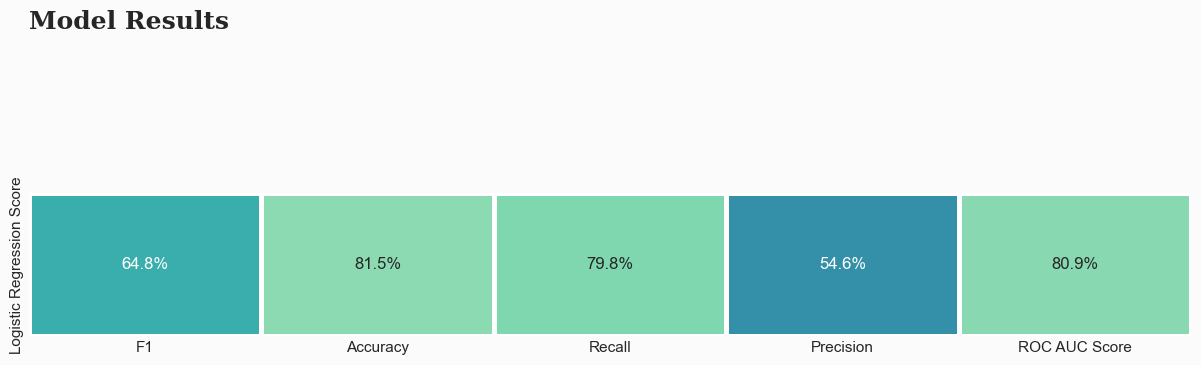

In [82]:
"""
Create the matrix of results
"""
df_models = round(pd.concat([lr_df], axis=1),3)

background_color = "#fbfbfb"
sns.set()
sns.set_palette(palette)

fig = plt.figure(figsize=(15,13)) # create figure
gs = fig.add_gridspec(5, 2)
gs.update(wspace=0.1, hspace=0.5)
ax0 = fig.add_subplot(gs[0, :])

sns.heatmap(df_models.T, cmap=cmap,annot=True,fmt=".1%",vmin=0,vmax=0.95, linewidths=2.5,cbar=False,ax=ax0,annot_kws={"fontsize":12})
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color) 

ax0.text(0,-1.15,'Model Results',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.tick_params(axis=u'both', which=u'both',length=0)

plt.savefig('model-results-matrix.png', dpi=400)
plt.show()

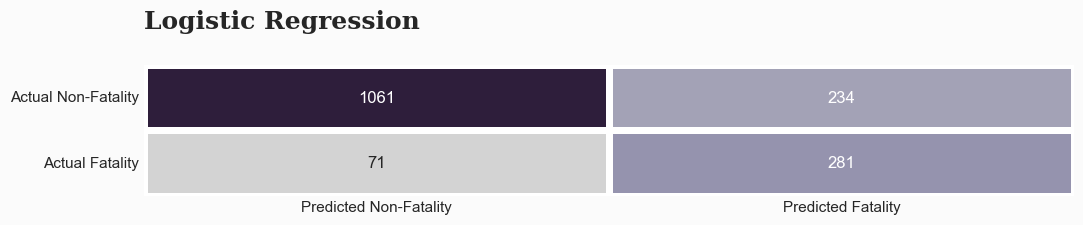

In [83]:
"""
Confusion Matrix
"""
# Plotting our results

logreg_cm  = confusion_matrix(y_test,logreg_tuned_pred )

colors = palette_r.as_hex()[4:]
colors.insert(0, "lightgray")

colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)


background_color = "#fbfbfb"

fig = plt.figure(figsize=(12,14)) # create figure
gs = fig.add_gridspec(5, 4)
gs.update(wspace=0.1, hspace=0.8)
ax0 = fig.add_subplot(gs[0, :])


ax0.set_facecolor(background_color) # axes background color

# Overall

sns.heatmap(logreg_cm, cmap=colormap,annot=True,fmt="d", linewidths=5,cbar=False,ax=ax0,
            yticklabels=['Actual Non-Fatality','Actual Fatality'],xticklabels=['Predicted Non-Fatality','Predicted Fatality'],annot_kws={"fontsize":12})



ax0.tick_params(axis=u'both', which=u'both',length=0)
background_color = "#fbfbfb"
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color) 


ax0.text(0,-0.55,'Logistic Regression',fontsize=18,fontweight='bold',fontfamily='serif')




plt.savefig('confusion-matrix.png', dpi=400)
plt.show()